# Task 1 Data Loading, Preprocessing & Exploratory Analysis

In [19]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("../src"))
from functions import load_data

os.makedirs("../figures", exist_ok=True)

## 1.1 Load and split the development dataset

In [20]:
data = load_data("../data/students_dataset.csv")

print(f"Students data shape: {data.shape}")
print(f"First 10 columns: {data.columns.tolist()[:10]}...")
print()
print(data.head())

Students data shape: (242, 14)
First 10 columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']...

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  48.0  1.0  4.0     124.0  274.0  0.0      2.0    166.0    0.0      0.5   
1  55.0  1.0  2.0     130.0  262.0  0.0      0.0    155.0    0.0      0.0   
2  54.0  0.0  2.0     132.0  288.0  1.0      2.0    159.0    1.0      0.0   
3  54.0  1.0  2.0     108.0  309.0  0.0      0.0    156.0    0.0      0.0   
4  57.0  0.0  4.0     140.0  241.0  0.0      0.0    123.0    1.0      0.2   

   slope   ca  thal  num  
0    2.0  0.0   7.0    1  
1    1.0  0.0   3.0    0  
2    1.0  1.0   3.0    0  
3    1.0  0.0   7.0    0  
4    2.0  0.0   7.0    1  


In [21]:
COL_NAMES = data.columns.tolist()
print(COL_NAMES)

print(f"\nDataset shape : {data.shape[0]} rows x {data.shape[1]} columns")
print("\nColumn dtypes:")
print(data.dtypes.to_string())

n_dupes = data.duplicated().sum()
print(f"\nDuplicate rows : {n_dupes}")

missing_values = data.isnull().sum()
print("\nMissing values per column:")
print(missing_values.to_string())

missing_pct = ((missing_values / len(data)) * 100).round(2)
print("\nMissing values percentage per column:")
print(missing_pct.to_string())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Dataset shape : 242 rows x 14 columns

Column dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64

Duplicate rows : 0

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        1
num         0

Missing values percentage per column:
age         0.00
sex         0.00
cp          0.00
trestbps    0.00
chol        0.00
fbs         0.00
restecg     0.00
thalach     0.00
exang       0.00
oldpeak     0.00
slope       0.00
ca          0.41
thal        0.41
num         0.00


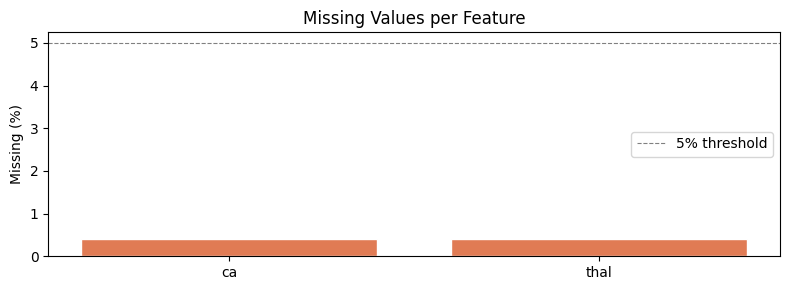

In [22]:
missing_df = pd.DataFrame({"Missing #": missing_values, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing #"] > 0]
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(missing_df.index, missing_df["Missing %"], color="#E07B54", edgecolor="white")
ax.set_ylabel("Missing (%)")
ax.set_title("Missing Values per Feature")
ax.axhline(5, ls="--", color="gray", lw=0.8, label="5% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/fig_missing_values.png", bbox_inches="tight")
plt.show()

In [23]:
print("\nDescriptive Statistics:")
print(data.describe(include="all").round(2).to_string())


Descriptive Statistics:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach   exang  oldpeak   slope      ca    thal     num
count  242.00  242.00  242.00    242.00  242.00  242.00   242.00   242.00  242.00   242.00  242.00  241.00  241.00  242.00
mean    54.55    0.68    3.15    130.96  249.84    0.14     0.98   149.96    0.33     1.00    1.59    0.61    4.71    0.46
std      9.00    0.47    0.98     17.62   52.85    0.35     1.00    22.69    0.47     1.12    0.61    0.88    1.95    0.50
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00    0.00     0.00    1.00    0.00    3.00    0.00
25%     48.00    0.00    2.25    120.00  212.00    0.00     0.00   134.50    0.00     0.00    1.00    0.00    3.00    0.00
50%     56.00    1.00    3.00    130.00  244.50    0.00     0.00   153.50    0.00     0.80    2.00    0.00    3.00    0.00
75%     61.00    1.00    4.00    140.00  277.75    0.00     2.00   166.00    1.00     1.60    2.00    1.00    7.00

### Class distribution impalance


Class distribution:
  0 (No disease): 131  (54.1%)
  1 (Disease)   : 111  (45.9%)
  Imbalance ratio (majority:minority) = 1.18:1


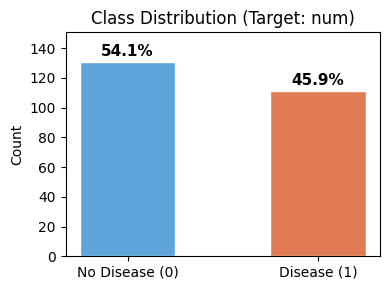

In [ ]:
class_counts = data["num"].value_counts().sort_index()
class_pct = (class_counts / len(data) * 100).round(1)
print(f"\nClass distribution:\n0 (No disease): {class_counts[0]} ({class_pct[0]}%)"
      f"\n1 (Disease) : {class_counts[1]} ({class_pct[1]}%)")
 
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Imbalance ratio (majority:minority) = {imbalance_ratio:.2f}:1")

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(["No Disease (0)", "Disease (1)"], class_counts.values,
              color=["#5DA5DA", "#E07B54"], edgecolor="white", width=0.5)
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{pct}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
ax.set_title("Class Distribution (Target: num)")
ax.set_ylim(0, max(class_counts) * 1.15)
plt.tight_layout()
plt.savefig("../figures/fig_class_distribution.png", bbox_inches="tight")
plt.show()

In [25]:
continuous_feats = ["age", "trestbps", "chol", "thalach", "oldpeak"]
for feat in continuous_feats:
    Q1 = data[feat].quantile(0.25)
    Q3 = data[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[((data[feat] < (Q1 - 1.5 * IQR)) | (data[feat] > (Q3 + 1.5 * IQR)))]
    print(f"Feature '{feat}': {len(outliers)} outliers detected ({len(outliers)/len(data)*100:.2f}%)")

Feature 'age': 0 outliers detected (0.00%)
Feature 'trestbps': 6 outliers detected (2.48%)
Feature 'chol': 5 outliers detected (2.07%)
Feature 'thalach': 1 outliers detected (0.41%)
Feature 'oldpeak': 4 outliers detected (1.65%)


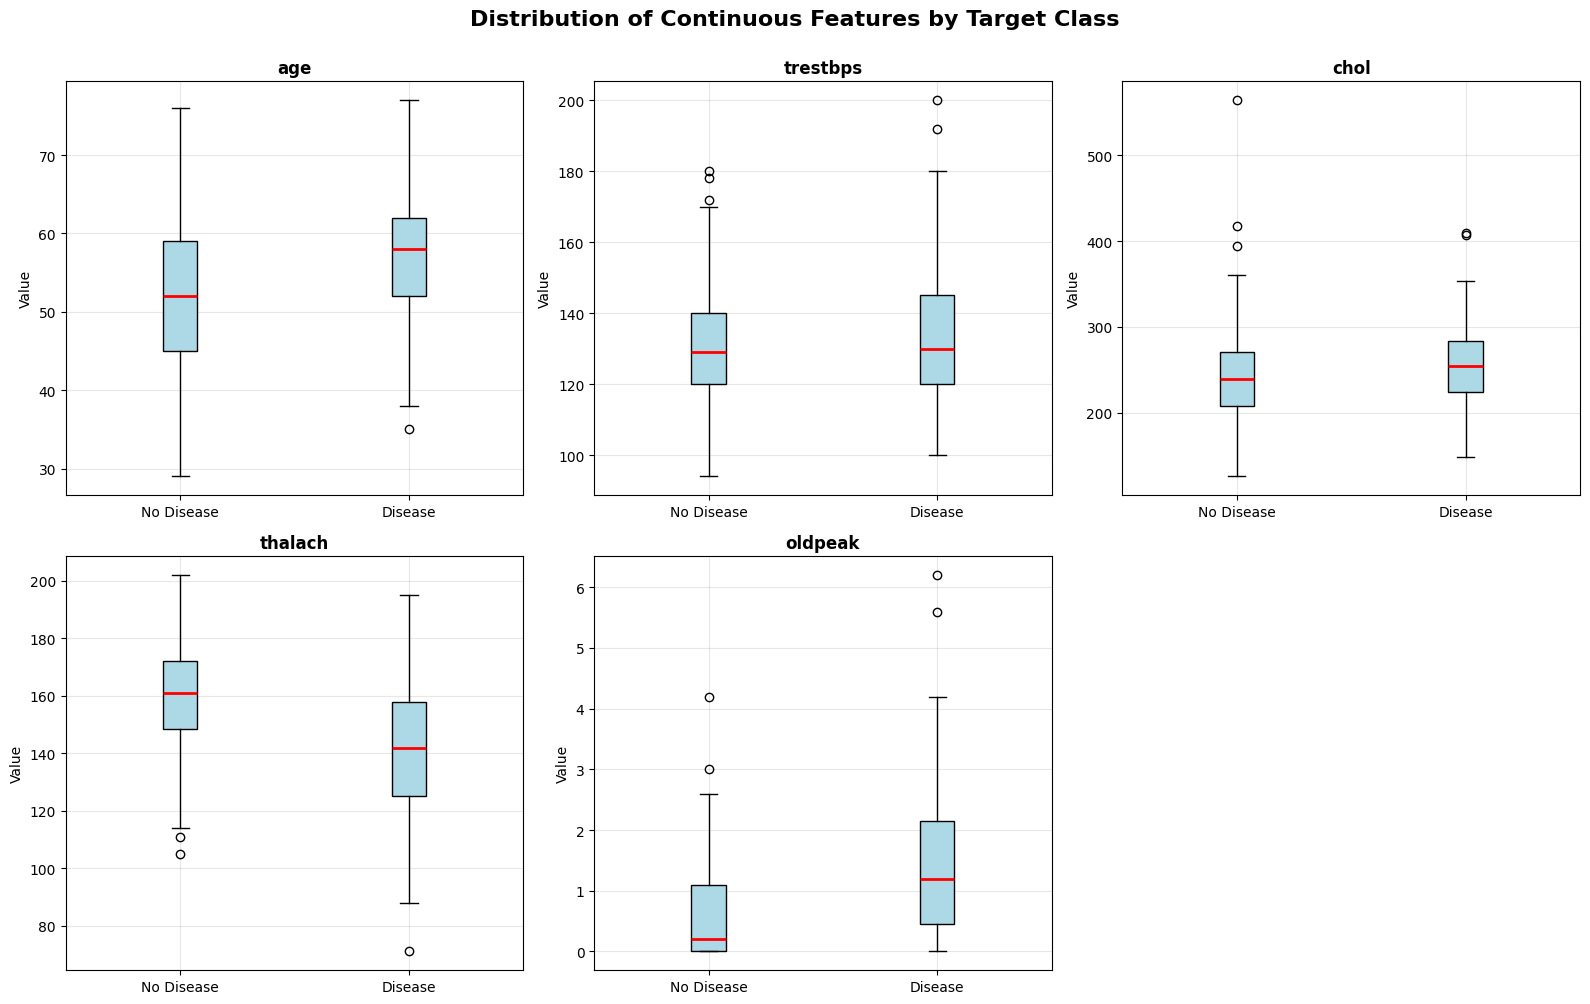

In [ ]:
CONTINUOUS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
BINARY = ["sex", "fbs", "exang"]
CATEGORICAL = ["cp", "restecg", "slope", "thal"]
ORDINAL = ["ca"]

# Box plots for continuous features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(CONTINUOUS):
    if col in data.columns and idx < len(axes):
        axes[idx].boxplot([data[data['num'] == 0][col].dropna(), 
                           data[data['num'] == 1][col].dropna()],
                          tick_labels=['No Disease', 'Disease'],
                          patch_artist=True,
                          boxprops=dict(facecolor='lightblue'),
                          medianprops=dict(color='red', linewidth=2))
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)

if len(CONTINUOUS) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Distribution of Continuous Features by Target Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("../figures/fig_continuous_boxplots.png", bbox_inches="tight")
plt.show()

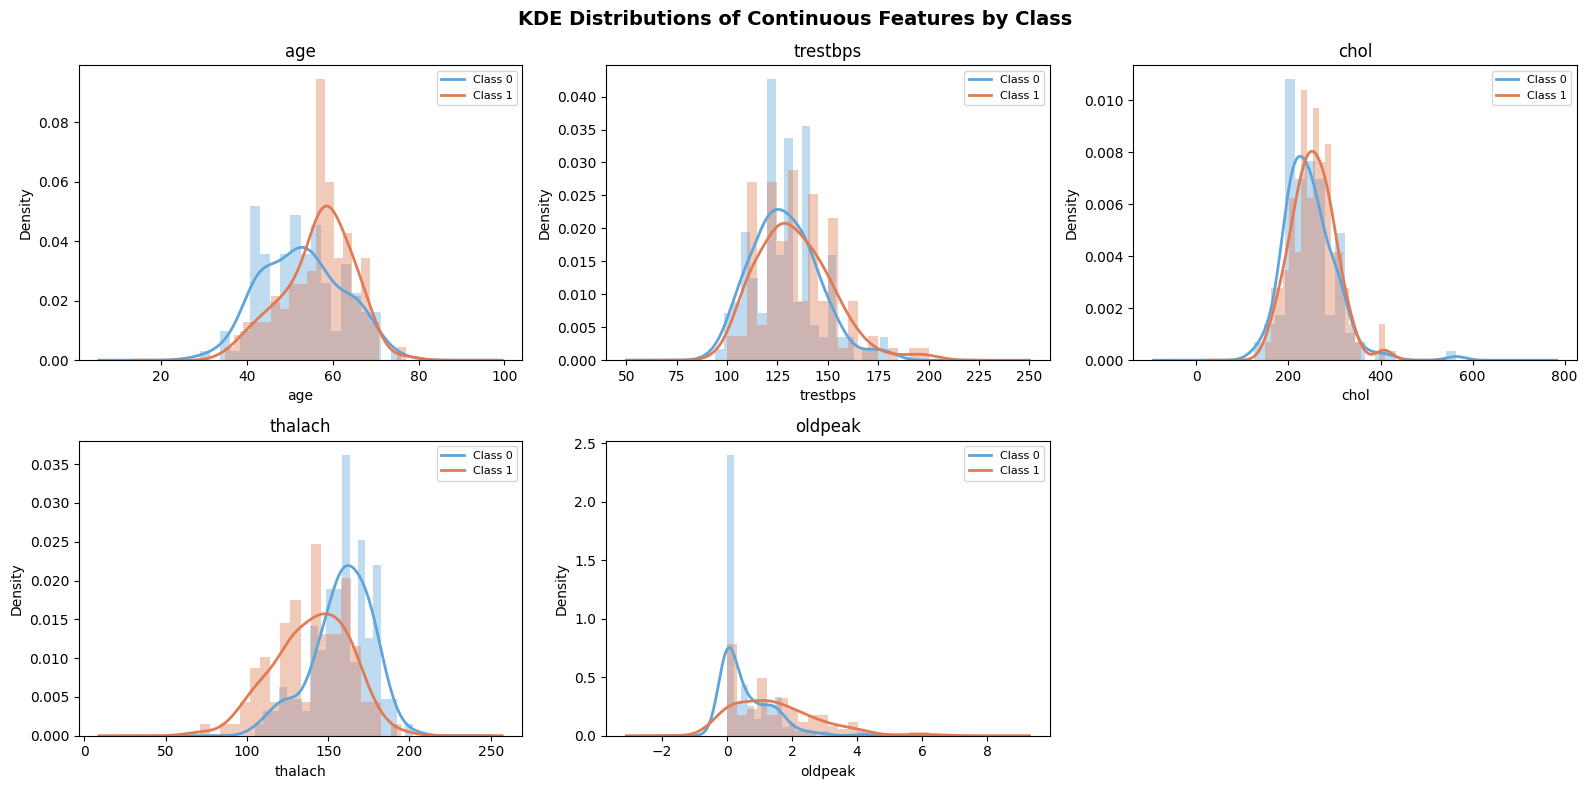

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(CONTINUOUS):
    for cls, color in [(0, "#5DA5DA"), (1, "#E07B54")]:
        vals = data.loc[data["num"] == cls, feat].dropna()
        axes[i].hist(vals, bins=20, alpha=0.4, color=color, density=True)
        vals.plot.kde(ax=axes[i], color=color, lw=2, label=f"Class {cls}")
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Density")
axes[-1].axis("off")
fig.suptitle("KDE Distributions of Continuous Features by Class", fontsize=14,
             fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/fig_kde_continuous.png", bbox_inches="tight")
plt.show()

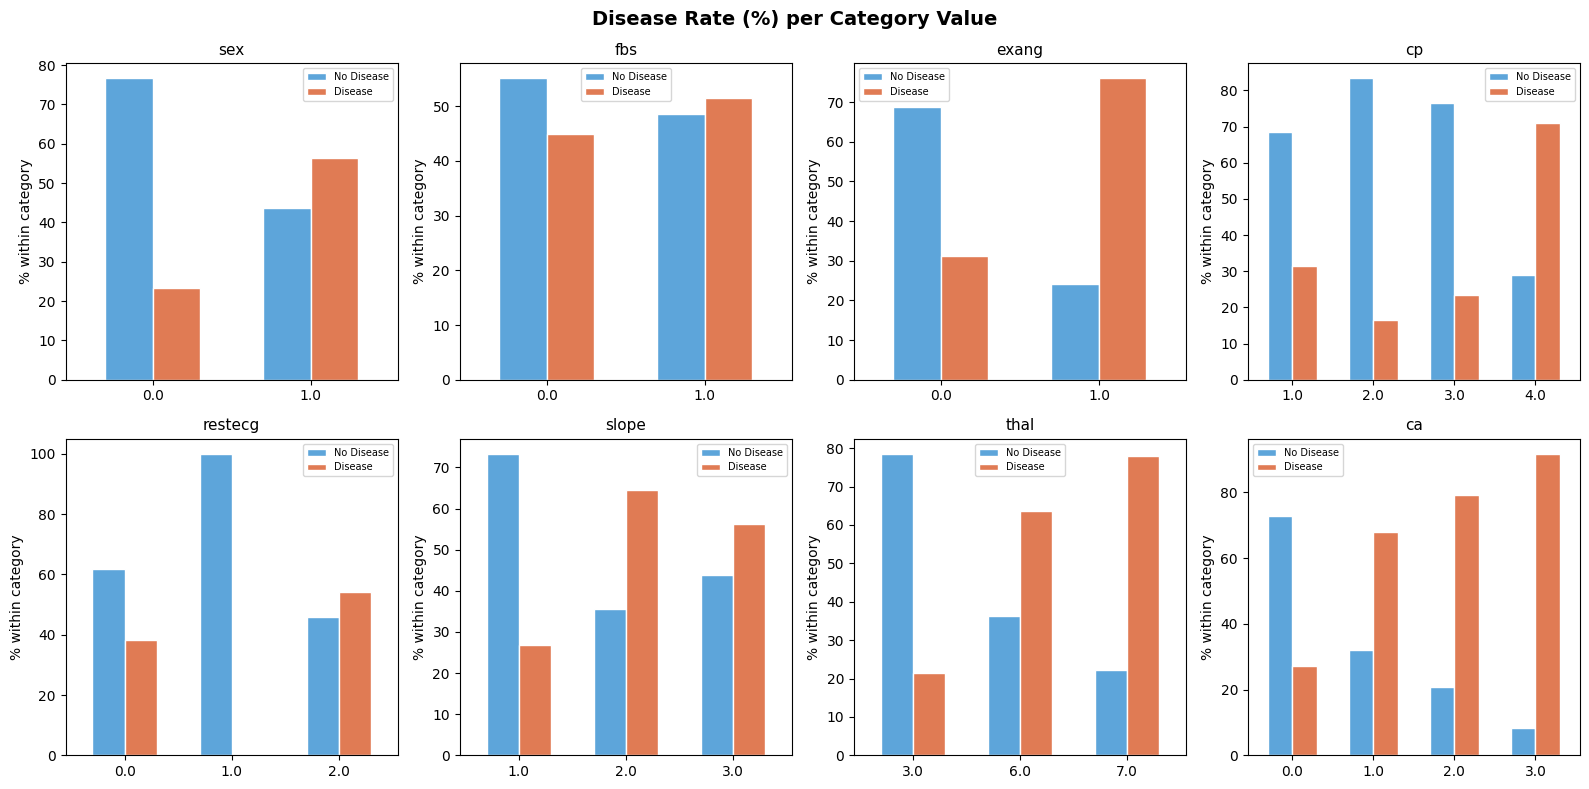

In [ ]:
cat_feats = BINARY + CATEGORICAL + ORDINAL
n_feats = len(cat_feats)
ncols = 4
nrows = (n_feats + ncols - 1) // ncols
 
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*4))
axes = axes.flatten()
 
for i, feat in enumerate(cat_feats):
    ct = pd.crosstab(data[feat], data["num"], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i], color=["#5DA5DA", "#E07B54"], edgecolor="white", width=0.6)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% within category")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(["No Disease", "Disease"], fontsize=7)
 
for j in range(i+1, len(axes)):
    axes[j].axis("off")
 
fig.suptitle("Disease Rate (%) per Category Value", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/fig_categorical_bars.png", bbox_inches="tight")
plt.show()

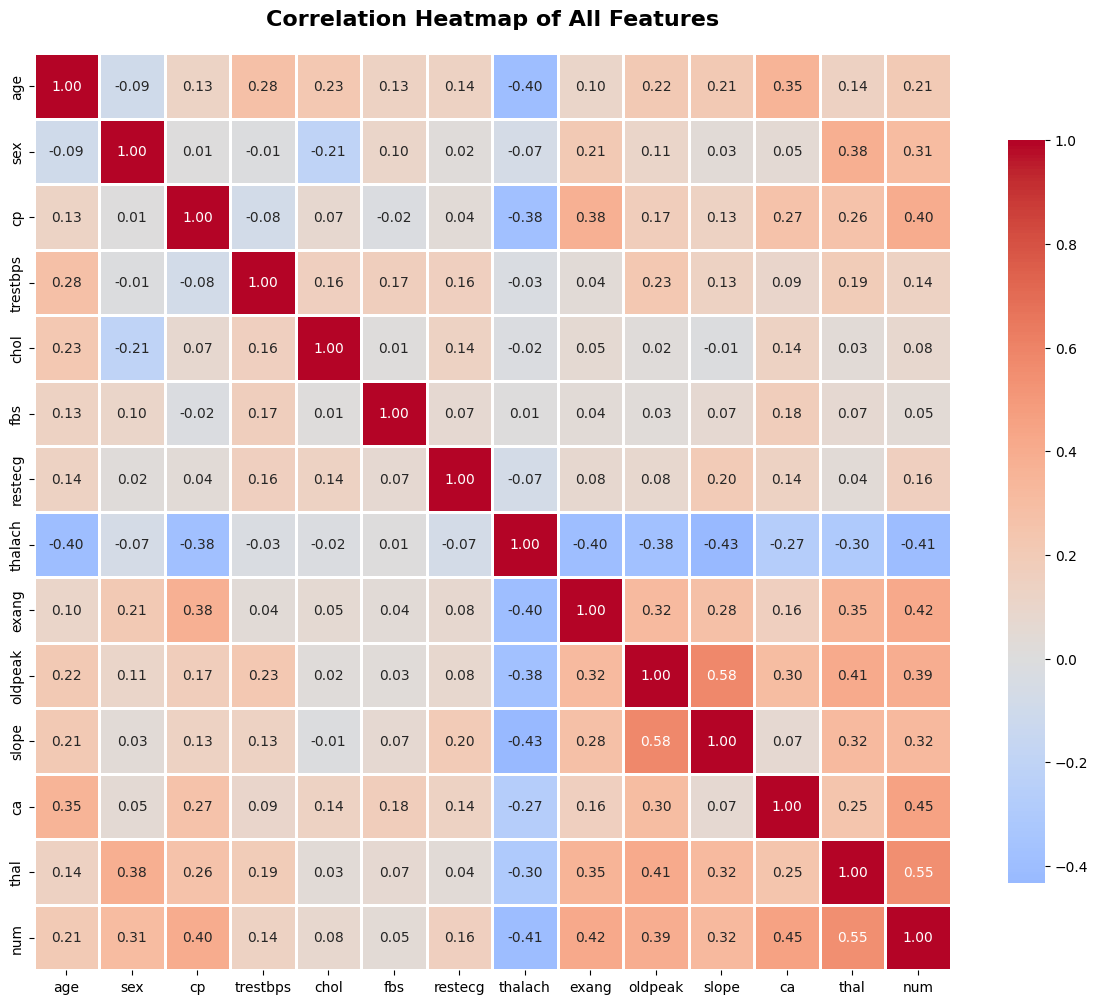

In [29]:
import seaborn as sns

# Compute correlation matrix
correlation_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../figures/fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

Correlation with Target Variable (sorted by absolute value):

thal        0.550479
ca          0.452629
exang       0.420280
thalach     0.409475
cp          0.400620
oldpeak     0.392151
slope       0.323349
sex         0.308342
age         0.209664
restecg     0.160363
trestbps    0.136085
chol        0.077191
fbs         0.045889
Name: num, dtype: float64


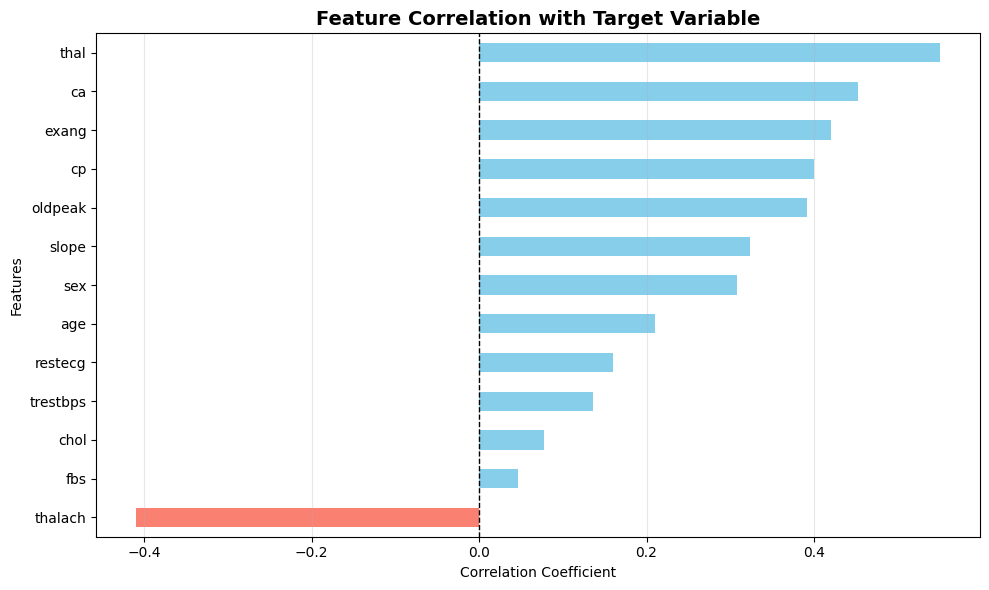

In [30]:
# Correlation with target variable
target_corr = correlation_matrix['num'].drop('num').sort_values(ascending=False)

print("Correlation with Target Variable (sorted by absolute value):\n")
print(target_corr.abs().sort_values(ascending=False))

# Visualize
plt.figure(figsize=(10, 6))
target_corr.sort_values().plot(kind='barh', color=['salmon' if x < 0 else 'skyblue' for x in target_corr.sort_values()])
plt.title('Feature Correlation with Target Variable', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("../figures/fig_target_correlation.png", bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X = data[numerical_features]
y = data['num']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print(f"Original number of features: {X.shape[1]}")
print(f"Number of principal components: {X_pca.shape[1]}")

PCA completed.
Original number of features: 5
Number of principal components: 5


In [32]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance by Component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components to explain 95% variance: {n_components_95}")


Explained Variance by Component:
PC1: 0.3672 (Cumulative: 0.3672)
PC2: 0.2231 (Cumulative: 0.5903)
PC3: 0.1774 (Cumulative: 0.7677)
PC4: 0.1416 (Cumulative: 0.9093)
PC5: 0.0907 (Cumulative: 1.0000)

Number of components to explain 95% variance: 5


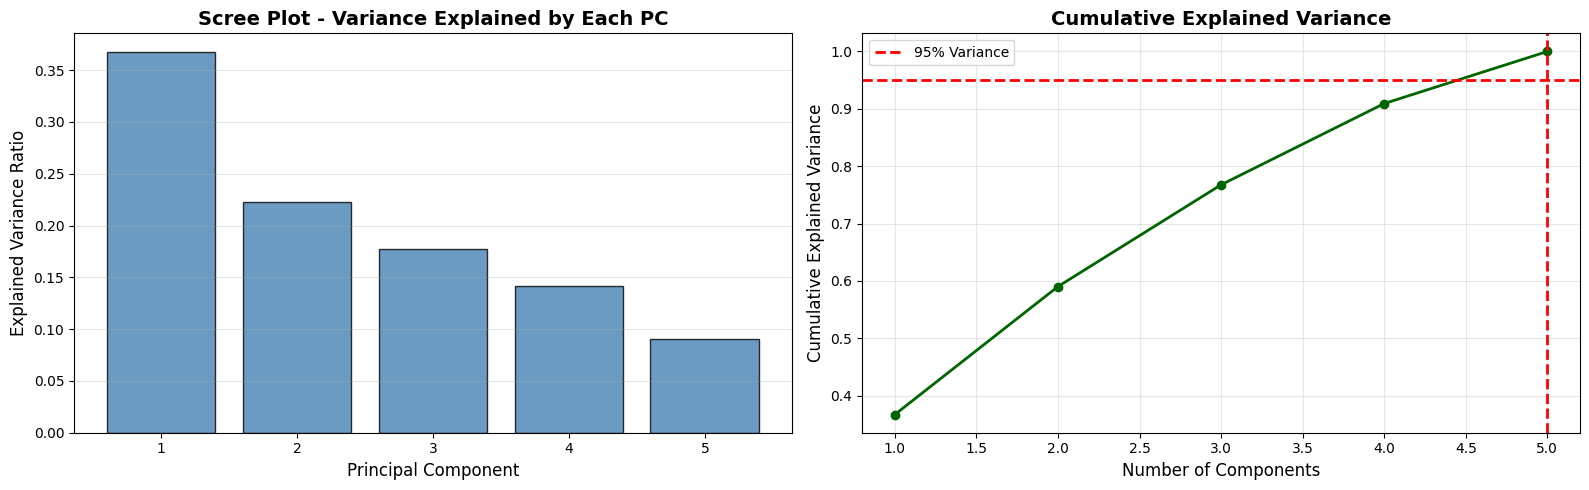

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance) + 1), explained_variance, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - Variance Explained by Each PC', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
            marker='o', linestyle='-', color='darkgreen', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Variance')
axes[1].axvline(x=n_components_95, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/fig_pca_variance.png", bbox_inches="tight")
plt.show()

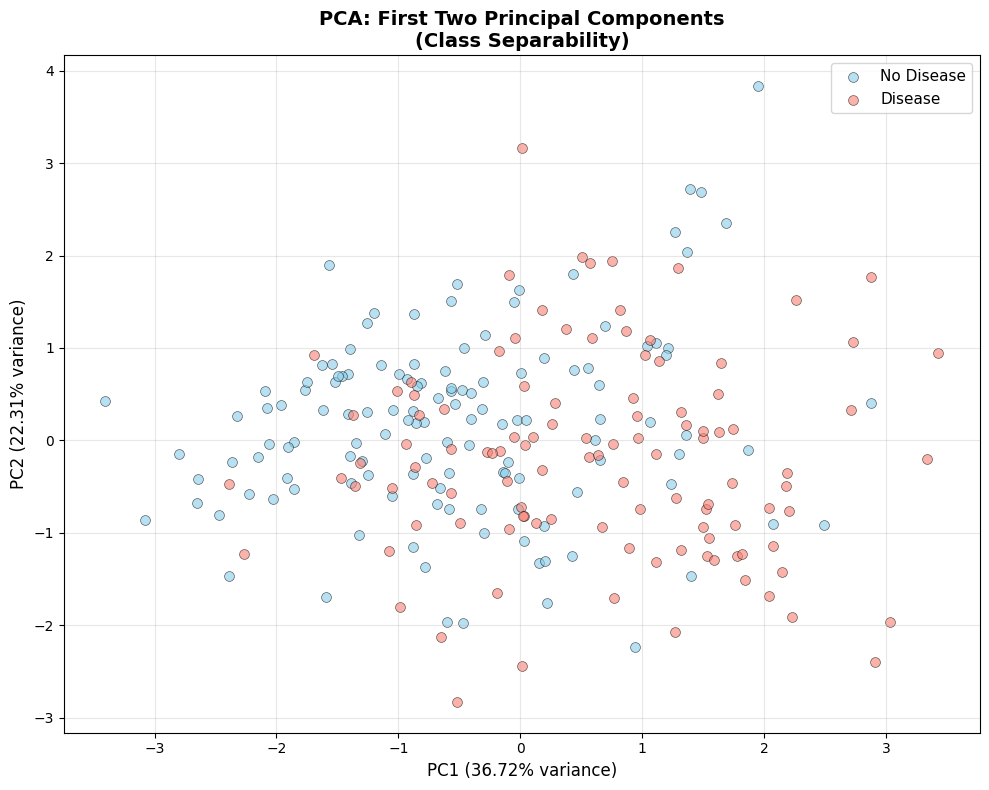

In [ ]:
# 2D PCA visualization (class separability)
plt.figure(figsize=(10, 8))

colors = ['skyblue', 'salmon']
labels = ['No Disease', 'Disease']

for class_val, color, label in zip([0, 1], colors, labels):
    mask = y == class_val
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance)', fontsize=12)
plt.title('PCA: First Two Principal Components\n(Class Separability)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/fig_pca_2d.png", bbox_inches="tight")
plt.show()